<a href="https://colab.research.google.com/github/vavan137/Yandex-Cup-2024/blob/main/A%20In%20Vino%20Veritas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df_exch = pd.read_csv('/content/roman_exchange_rates.csv')
df_exch.head(1)

,col_0,col_1,col_2
0,LXX,XXXIV-XII-XXIV,XL


Мне привычнее работать с арабскими цифрами...

In [ ]:
def roman_to_int(s):
  roman_numerals = {
      'I':1,
      'V':5,
      'X':10,
      'L':50,
      'C':100,
      'D':500,
      'M':1000
  }
  res = 0
  for i in range(len(s)):
    if i>0 and roman_numerals[s[i]]>roman_numerals[s[i-1]]:
      res += roman_numerals[s[i]] - 2*roman_numerals[s[i-1]]
    else:
      res += roman_numerals[s[i]]
  return res

In [ ]:
df_exch[['dt1','dt2','dt3']] = df_exch['col_1'].str.split('-',expand = True)
df_exch['newcol_0'] = df_exch['col_0'].apply(roman_to_int)
df_exch['newcol_dt1'] =  df_exch['dt1'].apply(roman_to_int)
df_exch['newcol_dt2'] =  df_exch['dt2'].apply(roman_to_int)
df_exch['newcol_dt3'] =  df_exch['dt3'].apply(roman_to_int)
df_exch['newcol_2'] = df_exch['col_2'].apply(roman_to_int)
df_exch.head(2)

,col_0,col_1,col_2,dt1,dt2,dt3,newcol_0,newcol_dt1,newcol_dt2,newcol_dt3,newcol_2
0,LXX,XXXIV-XII-XXIV,XL,XXXIV,XII,XXIV,70,34,12,24,40
1,LXX,XXXIV-XII-XXV,XXXIX,XXXIV,XII,XXV,70,34,12,25,39


on one day, the exchange rate was as follows: 1 gold = 40 silver = 70 bronze
Поэтому newcol_0 - Бронза, newcol_2 - Серебро.
dt1 - Год, dt2 - Месяц, dt3 - Дата

In [ ]:
df_exch['dt']= [f"{x}-{y}-{z}" for x, y, z in zip(df_exch['newcol_dt1'], df_exch['newcol_dt2'], df_exch['newcol_dt3'])]
df_exch['dt'] = pd.to_datetime(df_exch['dt'])
df_exch.tail(2)


,col_0,col_1,col_2,dt1,dt2,dt3,newcol_0,newcol_dt1,newcol_dt2,newcol_dt3,newcol_2,dt
2200,CXXI,XLI-I-I,XXV,XLI,I,I,121,41,1,1,25,2041-01-01
2201,CXX,XLI-I-II,XXV,XLI,I,II,120,41,1,2,25,2041-01-02


In [ ]:
df_exch = df_exch[['dt','newcol_0','newcol_2']].rename(columns = {'dt':'dt',
                                                        'newcol_0':'bronze',
                                                        'newcol_2':'silver'})
#df_exch

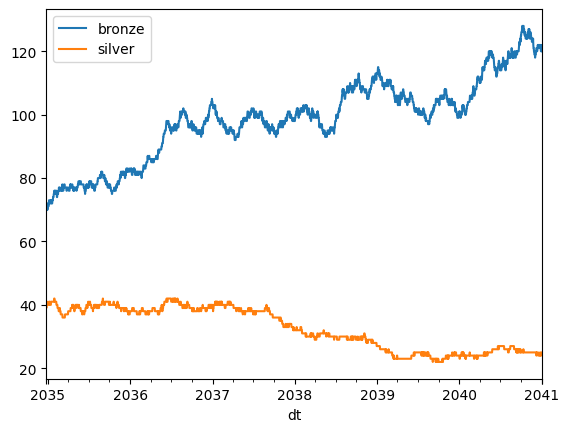

In [ ]:
import matplotlib.pyplot as plt
df_plot = df_exch[['dt','bronze','silver']]
 #
df_plot = df_plot.set_index('dt')
df_plot.plot()
plt.show()

It is reliably known that the denarius coin, during the period described in the ancient tables, had a trend of depreciation relative to the gold coin.
К годам добавили по 2000. Курс Динара снижался по отношению к золоту. Т.е. col_2 (Серебро) - Динар, col_0 - Квинар (Бронза). Aurus от Aurum - золото.

In [ ]:
df_trans = pd.read_csv('/content/roman_transactions.csv')
df_trans.head(2)

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7
0,Muniv,XXXIX,VIII,XXXI,Quinarius,VIII,XXIX,CXXIX
1,Murytub,XXXIX,IX,CXXI,Quinarius,V,VIII,CXXV


In [ ]:
df_trans['newcol_1'] = df_trans['col_1'].apply(roman_to_int)
df_trans['newcol_2'] = df_trans['col_2'].apply(roman_to_int)
df_trans['newcol_3'] = df_trans['col_3'].apply(roman_to_int)
df_trans['newcol_5'] = df_trans['col_5'].apply(roman_to_int)
df_trans['newcol_6'] = df_trans['col_6'].apply(roman_to_int)
df_trans['newcol_7'] = df_trans['col_7'].apply(roman_to_int)
df_trans.head(2)

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,newcol_1,newcol_2,newcol_3,newcol_5,newcol_6,newcol_7
0,Muniv,XXXIX,VIII,XXXI,Quinarius,VIII,XXIX,CXXIX,39,8,31,8,29,129
1,Murytub,XXXIX,IX,CXXI,Quinarius,V,VIII,CXXV,39,9,121,5,8,125


In [ ]:
df_work = df_trans[['col_0','newcol_1','newcol_2','newcol_3','col_4','newcol_5','newcol_6','newcol_7']]
df_work.describe()

,newcol_1,newcol_2,newcol_3,newcol_5,newcol_6,newcol_7
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,37.511150,6.484150,117.212650,5.938400,15.483400,525.359350
std,1.708222,3.451745,61.245627,1.674767,8.871238,749.277647
min,35.000000,1.000000,3.000000,1.000000,1.000000,1.000000
25%,36.000000,3.000000,41.000000,5.000000,8.000000,153.000000
50%,38.000000,6.000000,134.000000,6.000000,15.000000,349.000000
75%,39.000000,10.000000,165.000000,7.000000,23.000000,573.000000
max,41.000000,12.000000,278.000000,12.000000,31.000000,4249.000000


col_0 - продукт, вероятно записанный задом наперед
col_1 - Год
col_2 - Месяц или Индекс
col_3 - Объем или Цена
col_4 - Валюта
col_5 - Месяц или Индекс
col_6 - Дата
col_7 - Объем или Цена

The favor of the gods was determined daily in the Temple of Jupiter by tossing 12 fair coins.
Посмотрим распределение

col_5 - ближе к биномиальному распределению  (информация по каждому продукту каждый день, надеюсь)- приму за Индекс

In [ ]:
print(df_work['col_0'].unique())

['Muniv' 'Murytub' 'Atamora' 'Munarg' 'Suilis']


Добавлю дату в df_work

In [ ]:
df_work['dt']= [f"{x}-{y}-{z}" for x, y, z in zip(df_work['newcol_1'], df_work['newcol_2'], df_work['newcol_6'])]
df_work['dt'] = pd.to_datetime(df_work['dt'])

Нужна цена в единой валюте (например в золоте).
Добавим два тестовых поля (м.б. col_3 или col_7)

In [ ]:
import numpy as np
df = df_work.merge(df_exch, how='left',on='dt')
conditions = [(df['col_4']=='Aureus'),(df['col_4']=='Denarius'),(df['col_4']=='Quinarius') ]
choices_3 = [df['newcol_3'],df['newcol_3']/df['silver'],df['newcol_3']/df['bronze']]
choices_7 = [df['newcol_7'],df['newcol_7']/df['silver'],df['newcol_7']/df['bronze']]
df['test_price_col_3'] = np.select(conditions, choices_3, default=0)
df['test_price_col_7'] = np.select(conditions, choices_7, default=0)
#df = df[[]]
df.head(5)

,col_0,newcol_1,newcol_2,newcol_3,col_4,newcol_5,newcol_6,newcol_7,dt,bronze,silver,test_price_col_3,test_price_col_7
0,Muniv,39,8,31,Quinarius,8,29,129,2039-08-29,100,23,0.310000,1.290000
1,Murytub,39,9,121,Quinarius,5,8,125,2039-09-08,101,23,1.198020,1.237624
2,Murytub,40,8,117,Aureus,5,21,5,2040-08-21,120,27,117.000000,5.000000
3,Atamora,37,8,12,Quinarius,5,6,1337,2037-08-06,101,38,0.118812,13.237624
4,Murytub,40,12,140,Denarius,7,3,549,2040-12-03,119,25,5.600000,21.960000


The quantity of silk sold was distributed exponentially, while the quantity of grain was distributed uniformly. The quantity of the product sold is considered for each transaction

In one of the years, a severe drought occurred, which caused a significant spike in the average price of oil for several months, while the average price of spices, on the contrary, fell

In [ ]:
df2 = df[df['col_0']=='Munarg']

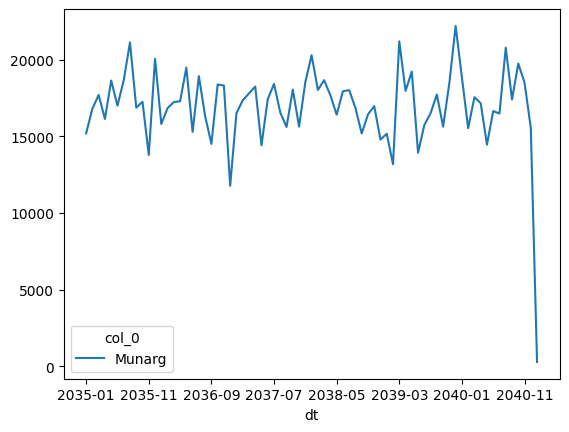

In [ ]:

df_plot_products = df2[['dt','col_0','newcol_3','newcol_7']]

monthly = (
    df_plot_products.groupby([pd.Grouper(key='dt', freq='M'), 'col_0'])['newcol_3']
    .sum()
    .unstack(fill_value=0)
)
monthly.index = monthly.index.strftime('%Y-%m')
monthly.plot()
plt.show()

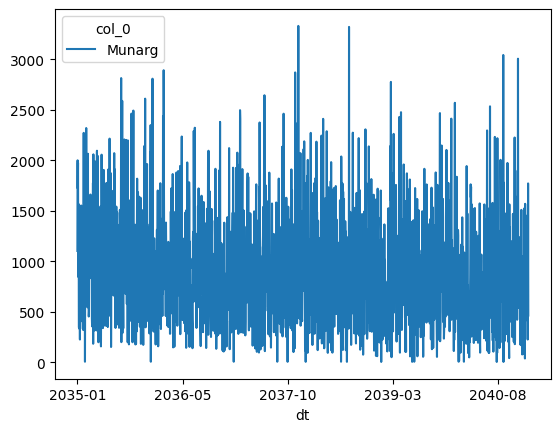

In [ ]:
df_plot_products = df2[['dt','col_0','newcol_3','newcol_7']]

monthly = (
    df_plot_products.groupby([pd.Grouper(key='dt', freq='D'), 'col_0'])['newcol_7']
    .sum()
    .unstack(fill_value=0)
)
monthly.index = monthly.index.strftime('%Y-%m')
monthly.plot()
plt.show()

Предположу, что уже из этих двух графиков видим, что newcol_3 - это Количество (следовательно, newcol_7 - это Цена)

In [ ]:
df.head(2)

,col_0,newcol_1,newcol_2,newcol_3,col_4,newcol_5,newcol_6,newcol_7,dt,bronze,silver,test_price_col_3,test_price_col_7
0,Muniv,39,8,31,Quinarius,8,29,129,2039-08-29,100,23,0.31000,1.290000
1,Murytub,39,9,121,Quinarius,5,8,125,2039-09-08,101,23,1.19802,1.237624


In [ ]:
df = df.rename(columns = {'col_0':'Продукт','newcol_1':'Год',
                     'newcol_2':'Месяц','newcol_3':'Количество','col_4':'Валюта',
                     'newcol_5':'Индекс','newcol_6':'День',
                     'newcol_7':'Цена',
                     'test_price_col_7':'Цена в Золоте'})
df.head(2)

,Продукт,Год,Месяц,Количество,Валюта,Индекс,День,Цена,dt,bronze,silver,test_price_col_3,Цена в Золоте
0,Muniv,39,8,31,Quinarius,8,29,129,2039-08-29,100,23,0.31000,1.290000
1,Murytub,39,9,121,Quinarius,5,8,125,2039-09-08,101,23,1.19802,1.237624


In [ ]:
df['Выручка'] = df['Количество']*df['Цена в Золоте']

In [ ]:
df.groupby('Продукт')['Выручка'].sum().sort_values(ascending=False)

,Выручка
Продукт,
Murytub,1.321652e+07
Munarg,8.674944e+06
Suilis,2.392599e+06
Muniv,9.187744e+05
Atamora,4.034478e+05


Ответ:

Product,Year,Month,Quantity,Currency,Index,Day,Price

Butter,Grain,Silk,Wine,Spices


Ниже (и позднее) проверю утверждения


The quantity of silk sold was distributed exponentially, while the quantity of grain was distributed uniformly. The quantity of the product sold is considered for each transaction

In one of the years, a severe drought occurred, which caused a significant spike in the average price of oil for several months, while the average price of spices, on the contrary, fell

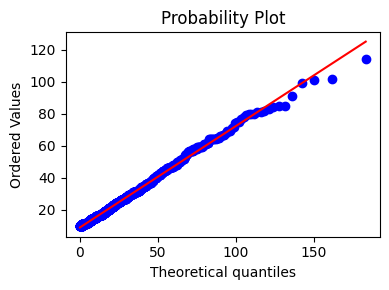

In [ ]:
from scipy import stats

sample_data = df.query("Продукт == 'Suilis'").Количество

fig,ax = plt.subplots(figsize=(4,3))
skewness = .0
lambda_estimate = 1 / sample_data.mean()
    # QQ-plot
stats.probplot(sample_data, dist='expon',
               sparams=(skewness, 1 / lambda_estimate), plot = ax)
plt.tight_layout()